# Aboveground Biomass Modeling via Earth Observation
prepared by Deha Agus Umarhadi and Asma Haghi for OpenGeoHub Summer School Hackathon

#### Introduction: 

Above ground biomass is an important indicator for terrestrial carbon storage, ecosystem productivity, forest structure,and the role of vegetation in global carbon cycle. EO provides an opportunity to estimate biomass over extensive regions by combining information from optical and radar satellite sensors with machine-learning methods. This notebook provides a machine learning workflow for predicting abovegroud biomass using the dataset provided for the aboveground biomass modeling via EO hackathon, LightGBM regression model is trained using selected EO and environmental predictors derived from Sentinel-2. Sentinel 1, PALSAR and ancillary information.

#### Objective: 
The main objective of this analysis is to develop and evaluate a machine-learning model capable of predicting aboveground biomass from multi-source Earth Observation variables.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import lightgbm
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split

### Data Preparation
#### Loading the training data
The supplied training dataset was imported as a Pandas DataFrame. Initial inspection was performed to identify the available response variable, spatial information, Earth Observation predictors, and ancillary variables.
The target variable used throughout the analysis was: biomass. The dataset additionally contained spatial coordinates, acquisition information, satellite-derived variables, bioregion, forest type, year, and tile identifiers.
Additional variables are added: NDVI and Canopy Height.
Canopy height data are extracted from ECHOSAT data (2018-2021).
#### Biomass quality control
Observations with biomass values less than or equal to zero were excluded from model development:
df_clean = df[df['biomass'] > 0]
This filtering step ensured that the model was trained using positive biomass observations.
Rows containing missing values in the variables used for the analysis were subsequently removed using complete-case filtering.
Following preprocessing, approximately 5.13 million observations were retained for model development.


#### Predictor Selection.
Twelve predictor variables were selected from the available EO and environmental information.
Sentinel-2 optical predictors
Three Sentinel-2 spectral bands were incorporated:
•	B02;
•	B04;
•	B08.
These bands provide information from the visible and near-infrared portions of the electromagnetic spectrum and therefore contain information related to vegetation reflectance and canopy properties.
An additional Sentinel-2 observation variable was also included.
PALSAR predictors
The PALSAR variables consisted of:
•	HH backscatter;
•	HV backscatter;
•	incidence angle;
•	PALSAR quality information.
Radar backscatter can provide complementary structural information to optical satellite measurements.
Sentinel-1 predictors
Two Sentinel-1 SAR predictors were included:
•	VV backscatter;
•	VH backscatter.
Environmental/categorical predictors
Two categorical variables were incorporated:
•	bioregion;
•	forest type.
Vegetation index:
•	NDVI.
ECHOSAT canopy height:
•	CH 2018-2021.

The final model therefore integrated information from multiple EO sources together with ecological context.



In [2]:
# Read training data
df = gpd.read_parquet("train_4326_ch_all.parquet")

In [3]:
# Add NDVI
df["ndvi"] = ((df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"] - df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]) / (df["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]+df["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]))

Data cleaning

In [4]:

df_clean = df[df['biomass'] > 0]

In [5]:
df_clean = df_clean.dropna(how='any')
df_clean

,Unnamed: 0,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,...,bioregion,forest_type,year,tile_id,geometry,canopy_height_2018,canopy_height_2019,canopy_height_2020,canopy_height_2021,ndvi
1,1,3.137125e+06,1.810804e+06,306.0,422.0,2632.0,10.0,-7.452171,-12.639405,51.086891,...,9.0,9.0,2020,38052,POINT (-3.54712 38.43217),773,774,768,775,0.723641
3,3,3.138085e+06,1.808544e+06,292.0,380.0,3400.0,8.0,-7.566631,-12.543831,47.825680,...,9.0,9.0,2020,38052,POINT (-3.53221 38.41357),928,929,932,932,0.798942
4,4,3.136835e+06,1.809904e+06,453.0,606.0,2684.0,11.0,-7.491881,-11.670959,43.808136,...,9.0,9.0,2020,38052,POINT (-3.54874 38.42368),746,746,748,755,0.631611
8,8,3.137595e+06,1.810824e+06,570.0,795.0,2452.0,9.0,-7.995021,-14.869256,26.739832,...,9.0,9.0,2020,38052,POINT (-3.54186 38.4331),763,773,787,799,0.510317
11,11,3.137915e+06,1.808924e+06,287.0,348.0,2386.0,9.0,-8.331754,-11.818994,29.713644,...,9.0,10.0,2020,38052,POINT (-3.53481 38.41668),628,638,656,676,0.745428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16019521,16019521,3.111665e+06,2.243934e+06,304.0,429.0,3516.0,9.0,-8.826680,-16.066385,35.457657,...,9.0,0.0,2019,35805,POINT (-4.70534 42.23312),1302,1328,1358,1390,0.782510
16019590,16019590,3.111625e+06,2.243884e+06,292.0,402.0,2464.0,9.0,-9.131854,-17.478987,35.740417,...,9.0,0.0,2019,35805,POINT (-4.70571 42.23261),879,884,879,888,0.719470
16019669,16019669,3.113105e+06,2.243804e+06,354.0,524.0,2906.0,9.0,-9.694338,-18.159117,38.063908,...,9.0,8.0,2019,35805,POINT (-4.68791 42.2345),1759,1779,1782,1780,0.694461
16019824,16019824,3.113075e+06,2.243834e+06,206.0,277.0,2818.0,10.0,-9.098869,-16.687696,38.181702,...,9.0,8.0,2019,35805,POINT (-4.68834 42.23471),1805,1817,1815,1842,0.821002


In [6]:
feature_cols = [
       'angle_palsar_xxxx',
       'b02_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b04_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b08_s2.cdse.quarterly_xxxx0401_xxxx0631', 
       'bioregion',
       'forest_type', 'HH_dB_palsar_xxxx', 'HV_dB_palsar_xxxx',
       'obs_s2.cdse.quarterly_xxxx0401_xxxx0631', 
       'qa_palsar_xxxx',
       'vh.sentinel1_xxxx07', 'vv.sentinel1_xxxx07',
       'ndvi', 'canopy_height_2018','canopy_height_2019','canopy_height_2020','canopy_height_2021']

In [7]:
x = df_clean[feature_cols]
x.columns

Index(['angle_palsar_xxxx', 'b02_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b04_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b08_s2.cdse.quarterly_xxxx0401_xxxx0631', 'bioregion', 'forest_type',
       'HH_dB_palsar_xxxx', 'HV_dB_palsar_xxxx',
       'obs_s2.cdse.quarterly_xxxx0401_xxxx0631', 'qa_palsar_xxxx',
       'vh.sentinel1_xxxx07', 'vv.sentinel1_xxxx07', 'ndvi',
       'canopy_height_2018', 'canopy_height_2019', 'canopy_height_2020',
       'canopy_height_2021'],
      dtype='object')

In [8]:
y = df_clean['biomass']
y

1            28.742064
3            61.379017
4            41.445705
8            25.911734
11           40.892021
               ...    
16019521     58.634174
16019590     60.487827
16019669    118.166924
16019824    104.021767
16019892     16.892933
Name: biomass, Length: 5128386, dtype: float64

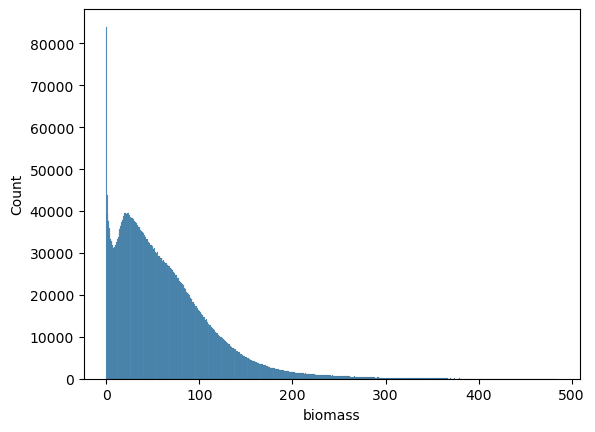

In [9]:
# Create a basic histogram
sns.histplot(data=df_clean, x="biomass")

# Display the plot
plt.show()

#### Training and Validation Strategy
The cleaned observations were separated into predictor variables, X, and the target variable, y, where:
[
y = \mathrm{Aboveground\ Biomass}
]
The dataset was then randomly divided into:
•	70% training data
•	30% testing data
using a fixed random state of 27.
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=27
)
The main issue of the reference data is the unbalanced biomass values, on the other hand, the data is quite large. Therefore, we downsampled the data to make them well distributed.


In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=27)

### Computational Environment
The analysis was implemented in Python using the following principal libraries:
•	Pandas and NumPy for data manipulation;
•	LightGBM for gradient-boosting regression;
•	Scikit-learn for data partitioning, cross-validation, hyperparameter optimization, and performance metrics;
•	Matplotlib for visualization;
•	SciPy for regression diagnostics; and
•	mpl-scatter-density for visualization of high-density observed-versus-predicted data.
A fixed random state was used during the training-test partition to improve reproducibility.


### LightGBM Model Development
LightGBM was selected as the regression algorithm because gradient-boosted decision trees can model nonlinear relationships and complex interactions among heterogeneous predictor variables.
This is particularly useful for EO-based biomass estimation, where relationships between satellite observations and biomass may be nonlinear and may vary according to vegetation structure and environmental conditions.The model was implemented using LGBMRegressor. The bioregion and forest_type variables were specified as categorical predictors during model fitting.


In [ ]:
import lightgbm as lgb

In [11]:
def evaluate_by_biomass(y_true, y_pred, n_bins=20):
    df = pd.DataFrame({"y": np.asarray(y_true), "pred": np.asarray(y_pred)})
    df["bin"] = pd.qcut(df["y"], q=n_bins, duplicates="drop")
    result = df.groupby("bin", observed=True).apply(lambda g: pd.Series({
        "N": len(g),
        "mean_y": g.y.mean(),
        "mean_pred": g.pred.mean(),
        "bias": (g.pred - g.y).mean(),
        "MAE": np.abs(g.pred - g.y).mean(),
        "RMSE": np.sqrt(np.mean((g.pred - g.y) ** 2)),
        "R2": r2_score(g.y, g.pred) if len(g) > 1 else np.nan
    }), include_groups=False)
    return result.reset_index()

def evaluate_overall(y_true, y_pred, name="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

params = {
    "objective": "regression",
    "n_estimators": 5000,
    "learning_rate": 0.1,
    "num_leaves": 40
}



In [13]:
n_bins = 30
bins = np.linspace(y_train.min(), y_train.max(), n_bins + 1)
train_bins = pd.cut(y_train, bins=bins, include_lowest=True)

bin_counts = train_bins.value_counts().sort_index()
bin_frequency = train_bins.map(bin_counts)

In [14]:
# Random downsampling of dense biomass regions
# Keep at most this many samples per biomass bin.
max_per_bin = int(bin_counts.quantile(0.5))

train_df = pd.DataFrame({"index": np.arange(len(y_train)), "y": np.asarray(y_train)})
train_df["bin"] = pd.cut(train_df["y"], bins=bins, include_lowest=True)

sampled_indices = train_df.groupby("bin", observed=True, group_keys=False).apply(
    lambda g: g.sample(n=min(len(g), max_per_bin), random_state=42),
    include_groups=False
)["index"].values

X_train_down = X_train.iloc[sampled_indices] if hasattr(X_train, "iloc") else X_train[sampled_indices]
y_train_down = np.asarray(y_train)[sampled_indices]

print(f"\nOriginal training samples: {len(y_train):,}")
print(f"Downsampled training samples: {len(y_train_down):,}")

model_down = lightgbm.LGBMRegressor(**params)
model_down.fit(X_train_down, y_train_down)

pred_down = model_down.predict(X_test)
evaluate_overall(y_test, pred_down, "DOWNSAMPLED")
down_results = evaluate_by_biomass(y_test, pred_down)


Original training samples: 3,589,870
Downsampled training samples: 215,317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3613
[LightGBM] [Info] Number of data points in the train set: 215317, number of used features: 17
[LightGBM] [Info] Start training from score 149.481602
DOWNSAMPLED: RMSE=28.4909, MAE=19.2390, R2=0.6976


In [15]:
print(down_results.to_string(index=False))


                          bin       N     mean_y  mean_pred      bias       MAE      RMSE          R2
(-0.00099999999999727, 4.006] 76926.0   1.626328  11.627817 10.001489 10.760570 19.023347 -234.071743
               (4.006, 9.801] 76926.0   6.865038  18.426035 11.560997 12.690347 20.567672 -149.265185
              (9.801, 15.347] 76926.0  12.642624  24.569006 11.926382 13.496669 22.000411 -188.385100
             (15.347, 20.266] 76926.0  17.842256  28.759930 10.917674 13.604567 22.114008 -241.660618
             (20.266, 25.048] 76925.0  22.654196  33.165199 10.511003 14.265764 23.341997 -286.936055
             (25.048, 29.946] 76926.0  27.478616  37.669307 10.190692 15.084557 24.304720 -294.754086
             (29.946, 35.035] 76926.0  32.471412  42.520282 10.048870 16.211436 25.585760 -300.524913
             (35.035, 40.367] 76926.0  37.683457  47.804204 10.120747 17.492328 27.032927 -307.362032
             (40.367, 45.993] 76925.0  43.161948  53.383500 10.221552 18.717083 28

#### Model Evaluation
identified during grid search.
Model performance was evaluated using several complementary statistics.
Coefficient of determination
[
R^2 \approx 0.697
]
The model therefore explained approximately 64% of the variability in biomass within the held-out test data.
Mean Absolute Error
[
MAE \approx 19.24;t/ha
]
The MAE represents the average absolute difference between predicted and reference biomass.
Root Mean Squared Error
The RMSE obtained from the evaluation was approximately:
[
RMSE \approx 28.49;t/ha
]
Because RMSE places greater weight on large prediction errors, it provides a useful measure of model performance where large biomass prediction errors are particularly undesirable.
Overall, the evaluation demonstrates that the multi-source EO predictors contain substantial information for estimating aboveground biomass.



In [16]:
print('r2 = ', r2_score(y_test, pred_down), ', ' ,
     'mse = ', np.sqrt(mean_squared_error(y_test, pred_down)), ', ' ,
     'mae = ', mean_absolute_error(y_test, pred_down))

r2 =  0.6976481817786555 ,  mse =  28.490929469374564 ,  mae =  19.238962530578448


##### Reference versus Predicted Biomass
A density-based scatter plot was generated to compare reference biomass observations with LightGBM predictions.
The figure contains:
•	individual prediction density;
•	a 1:1 reference line;
•	a fitted regression line;
•	sample size;
•	prediction bias;
•	MAE;
•	RMSE; and
•	R².
The 1:1 line represents perfect agreement between reference and predicted biomass. Concentration of observations around this line indicates stronger predictive agreement.
The density representation was particularly useful because the test dataset contained a very large number of observations, making a conventional scatter plot difficult to interpret.
Figure: Reference versus LightGBM-predicted aboveground biomass.
The overall relationship indicates that the model successfully reproduces a substantial component of the observed biomass variability. Nevertheless, deviations from the 1:1 line indicate remaining prediction uncertainty, particularly across portions of the biomass range.

In [17]:
import mpl_scatter_density
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress

white_magma = LinearSegmentedColormap.from_list('white_magma', [
    (0, '#ffffff'),  # White
    (1e-20, '#000004'),  # Deep black-purple (magma start)
    (0.2, '#3b0f70'),  # Dark purple
    (0.4, '#8c2981'),  # Reddish purple
    (0.6, '#de4968'),  # Red
    (0.8, '#fca636'),  # Orange
    (1, '#fcfdbf'),  # Yellow (magma end)
], N=256)

def using_mpl_scatter_density(ax, x, y):
    # Use the provided Axes object instead of creating one
    density = ax.scatter_density(x, y, cmap=white_magma, vmin=0, vmax=800)
    ax.figure.colorbar(density, ax=ax, label='Number of points per pixel')

/opt/anaconda3/envs/tf_chm/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/envs/tf_chm/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


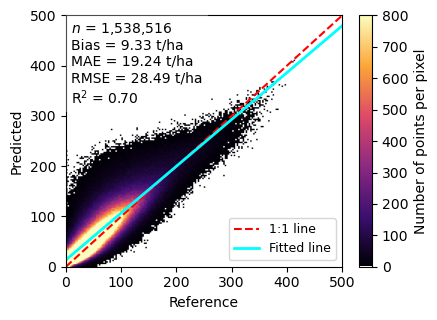

In [18]:
# x = y_test
y_pred = pred_down

n = len(y_test)

bias = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(y_test, y_pred)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(4.7, 3.3),
    subplot_kw={'projection': 'scatter_density'}
)

# Density scatter
using_mpl_scatter_density(ax, y_test, y_pred)

# 1:1 line
ax.plot([0, 700], [0, 700], 'r--', lw=1.5, label='1:1 line')

# Fitted regression line
xx = np.linspace(0, 700, 1000)
yy = intercept + slope * xx
ax.plot(xx, yy, color='cyan', lw=2,
        label=f'Fitted line')

# Labels and limits
ax.set_xlabel("Reference")
ax.set_ylabel("Predicted")
ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
ax.set_xticks(np.arange(0, 600, 100))
ax.set_yticks(np.arange(0, 600, 100))

# Statistics textbox
stats_text = (
    f"$n$ = {n:,}\n"
    f"Bias = {bias:.2f} t/ha\n"
    f"MAE = {mae:.2f} t/ha\n"
    f"RMSE = {rmse:.2f} t/ha\n"
    f"R$^2$ = {r2:.2f}"
)

ax.text(
    0.02, 0.98,
    stats_text,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
)

ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("agb_testing.png", dpi=400)
plt.show()


##### Feature Importance

Feature importance was evaluated from the optimized LightGBM model using gain-based importance.
Gain represents the improvement in the model objective attributable to splits involving each predictor across the ensemble of trees. Predictors producing greater cumulative gains therefore contributed more strongly to model predictions.
The feature-importance analysis provides an interpretable assessment of the relative contributions of:
•	Sentinel-2 optical observations;
•	Sentinel-1 SAR observations;
•	PALSAR measurements;
•	Canopy height;
•	bioregion; and
•	forest type.
This step is particularly useful in EO applications because predictive performance alone does not indicate which satellite observations provide the greatest information for biomass estimation.
Figure: Gain-based feature importance of the optimized LightGBM biomass model.

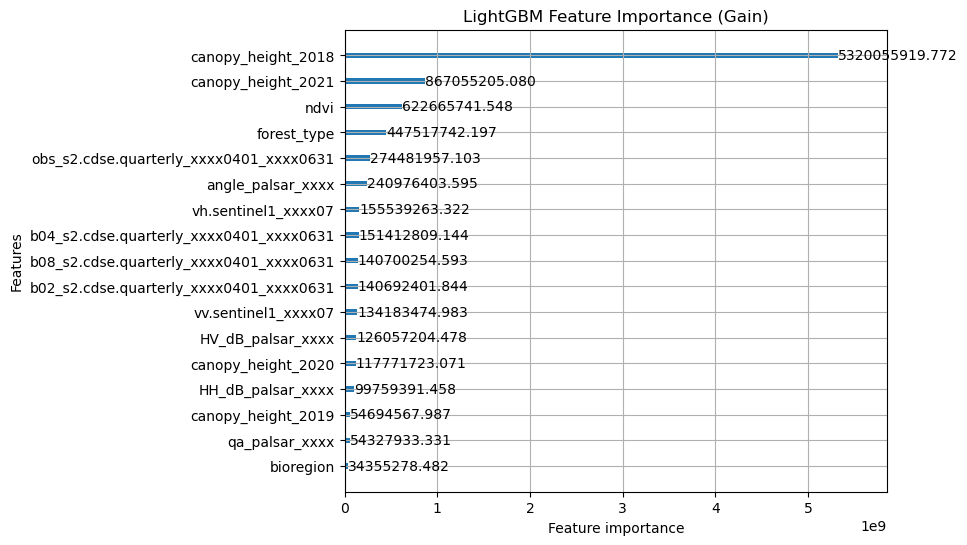

In [19]:
# Plot feature importance using Gain
lightgbm.plot_importance(model_down, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()


In [68]:
# Save the model
pickle.dump(model_down, open("./model/LGBMmodel_ndvi_ch_downsampled.pickle", "wb"))



##### Prediction of the Competition Test Data
Following model development and evaluation, the competition test dataset was imported for prediction.
The same predictor structure used during training was retained to ensure consistency between training and inference.
Missing-value inspection identified a small number of test observations containing incomplete predictor information. These observations were separated from complete cases prior to prediction so that missing information was not inadvertently passed to the fitted model without an explicit treatment strategy.
The optimized LightGBM estimator was then used to generate biomass predictions for valid test observations.
This stage forms the basis for preparing the final competition submission.



In [20]:
df_test = gpd.read_parquet("test_4326_ch_all.parquet")
df_test


,Unnamed: 0,row_id,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,...,year,tile_id,geometry,longitude,latitude,canopy_height,canopy_height_2018,canopy_height_2019,canopy_height_2020,canopy_height_2021
0,24,028631_3040064_2251003,3.040065e+06,2.251004e+06,100.0,103.0,2788.0,21.0,-10.144670,-13.913869,...,2021,28631,POINT (-5.57242 42.1662),-5.572416,42.166201,3306,3306,3301,3307,3341
1,30,028631_3041214_2252063,3.041215e+06,2.252064e+06,171.0,208.0,2746.0,20.0,-7.349724,-10.590984,...,2021,28631,POINT (-5.56121 42.17768),-5.561211,42.177681,2869,2869,2902,2908,2963
2,33,028631_3041184_2251693,3.041185e+06,2.251694e+06,98.0,91.0,3664.0,21.0,-6.874915,-12.238380,...,2021,28631,POINT (-5.56071 42.17436),-5.560713,42.174364,3046,3046,3046,3046,3061
3,38,028631_3039864_2250783,3.039865e+06,2.250784e+06,98.0,131.0,3060.0,20.0,-5.991528,-10.575653,...,2021,28631,POINT (-5.57428 42.16389),-5.574282,42.163890,3328,3328,3329,3333,3333
4,64,028631_3040224_2251483,3.040225e+06,2.251484e+06,72.0,88.0,3772.0,22.0,-6.046557,-10.341457,...,2021,28631,POINT (-5.57163 42.17073),-5.571626,42.170730,2561,2561,2568,2565,2595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,884113,061751_3374644_2043173,3.374645e+06,2.043174e+06,287.0,323.0,4392.0,17.0,-9.803984,-15.310058,...,2020,61751,POINT (-1.21909 40.85472),-1.219088,40.854718,1453,1453,1463,1483,1505
45015,885387,061751_3374594_2043203,3.374595e+06,2.043204e+06,608.0,922.0,3732.0,17.0,-11.813272,-15.730301,...,2020,61751,POINT (-1.21972 40.85492),-1.219722,40.854919,1788,1788,1818,1832,1820
45016,890670,061751_3374624_2043173,3.374625e+06,2.043174e+06,212.0,268.0,3086.0,17.0,-11.729067,-16.882254,...,2020,61751,POINT (-1.21932 40.85469),-1.219322,40.854691,1899,1899,1934,1944,1984
45017,895641,061751_3374614_2043223,3.374615e+06,2.043224e+06,153.0,215.0,3280.0,17.0,-7.831328,-13.507510,...,2020,61751,POINT (-1.21952 40.85512),-1.219520,40.855125,2182,2182,2200,2216,2190


In [21]:
df_test["ndvi"] = ((df_test["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"] - df_test["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]) / (df_test["b08_s2.cdse.quarterly_xxxx0401_xxxx0631"]+df_test["b04_s2.cdse.quarterly_xxxx0401_xxxx0631"]))

In [22]:
x_test = df_test[feature_cols]
x_test.columns

Index(['angle_palsar_xxxx', 'b02_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b04_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b08_s2.cdse.quarterly_xxxx0401_xxxx0631', 'bioregion', 'forest_type',
       'HH_dB_palsar_xxxx', 'HV_dB_palsar_xxxx',
       'obs_s2.cdse.quarterly_xxxx0401_xxxx0631', 'qa_palsar_xxxx',
       'vh.sentinel1_xxxx07', 'vv.sentinel1_xxxx07', 'ndvi',
       'canopy_height_2018', 'canopy_height_2019', 'canopy_height_2020',
       'canopy_height_2021'],
      dtype='object')

In [23]:
y_test_pred = model_down.predict(x_test)
y_test_pred


array([319.10054856, 314.7734368 , 293.89427792, ..., 199.52280076,
       231.17033793, 212.95337295])

In [24]:
y_test_pred.min()

-101.65771649133322

In [25]:
df_test['Expected'] = y_test_pred
df_test["Id"] = df_test["row_id"]

In [26]:
df_test

,Unnamed: 0,row_id,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,...,longitude,latitude,canopy_height,canopy_height_2018,canopy_height_2019,canopy_height_2020,canopy_height_2021,ndvi,Expected,Id
0,24,028631_3040064_2251003,3.040065e+06,2.251004e+06,100.0,103.0,2788.0,21.0,-10.144670,-13.913869,...,-5.572416,42.166201,3306,3306,3301,3307,3341,0.928744,319.100549,028631_3040064_2251003
1,30,028631_3041214_2252063,3.041215e+06,2.252064e+06,171.0,208.0,2746.0,20.0,-7.349724,-10.590984,...,-5.561211,42.177681,2869,2869,2902,2908,2963,0.859174,314.773437,028631_3041214_2252063
2,33,028631_3041184_2251693,3.041185e+06,2.251694e+06,98.0,91.0,3664.0,21.0,-6.874915,-12.238380,...,-5.560713,42.174364,3046,3046,3046,3046,3061,0.951531,293.894278,028631_3041184_2251693
3,38,028631_3039864_2250783,3.039865e+06,2.250784e+06,98.0,131.0,3060.0,20.0,-5.991528,-10.575653,...,-5.574282,42.163890,3328,3328,3329,3333,3333,0.917894,359.593802,028631_3039864_2250783
4,64,028631_3040224_2251483,3.040225e+06,2.251484e+06,72.0,88.0,3772.0,22.0,-6.046557,-10.341457,...,-5.571626,42.170730,2561,2561,2568,2565,2595,0.954404,343.769131,028631_3040224_2251483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,884113,061751_3374644_2043173,3.374645e+06,2.043174e+06,287.0,323.0,4392.0,17.0,-9.803984,-15.310058,...,-1.219088,40.854718,1453,1453,1463,1483,1505,0.862990,121.716144,061751_3374644_2043173
45015,885387,061751_3374594_2043203,3.374595e+06,2.043204e+06,608.0,922.0,3732.0,17.0,-11.813272,-15.730301,...,-1.219722,40.854919,1788,1788,1818,1832,1820,0.603782,189.368271,061751_3374594_2043203
45016,890670,061751_3374624_2043173,3.374625e+06,2.043174e+06,212.0,268.0,3086.0,17.0,-11.729067,-16.882254,...,-1.219322,40.854691,1899,1899,1934,1944,1984,0.840191,199.522801,061751_3374624_2043173
45017,895641,061751_3374614_2043223,3.374615e+06,2.043224e+06,153.0,215.0,3280.0,17.0,-7.831328,-13.507510,...,-1.219520,40.855125,2182,2182,2200,2216,2190,0.876967,231.170338,061751_3374614_2043223


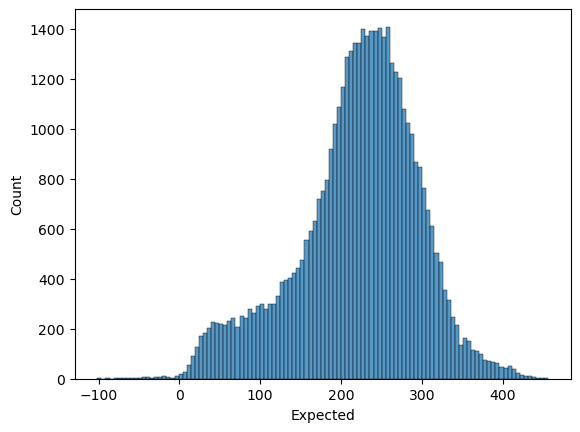

In [27]:
# Create a basic histogram
sns.histplot(data=df_test, x="Expected")

# Display the plot
plt.show()

In [28]:
# Clip the negative values
df_test['Expected'] = df_test['Expected'].clip(lower=0)

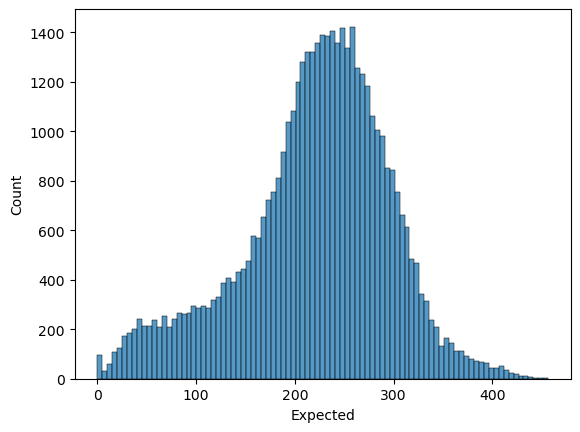

In [29]:
# Create a basic histogram
sns.histplot(data=df_test, x="Expected")

# Display the plot
plt.show()

In [30]:
df_test_pred = df_test[["Id", "Expected"]]
df_test_pred.reset_index(drop=True)

,Id,Expected
0,028631_3040064_2251003,319.100549
1,028631_3041214_2252063,314.773437
2,028631_3041184_2251693,293.894278
3,028631_3039864_2250783,359.593802
4,028631_3040224_2251483,343.769131
...,...,...
45014,061751_3374644_2043173,121.716144
45015,061751_3374594_2043203,189.368271
45016,061751_3374624_2043173,199.522801
45017,061751_3374614_2043223,231.170338


In [45]:
df_test_pred.to_csv("submission_ndvi_ch_multiyear_lgbm5000_downsampled.csv", index=False)

#### Conclusion
This hackathon analysis developed a computational workflow for estimating aboveground biomass from multi-source Earth Observation information using LightGBM.
After data quality control, approximately 5.13 million valid biomass observations were used in the analysis. Several predictors representing Sentinel-2 optical observations, Sentinel-1 and PALSAR radar information, vegetaion index, canopy height, and ecological categorical variables were selected for model development.
The model training was conducted using 5000 estimators and num_leaves of 40.
Model strategy included the data downsampling.

Evaluation against the held-out test subset produced an R² of 0.70, MAE of 19.24 t/ha, and an RMSE of 28.49 t/ha.
The results indicate that LightGBM can effectively integrate heterogeneous EO observations for large-scale aboveground biomass prediction. At the same time, the remaining prediction errors and limitations of random spatial sampling highlight opportunities for further improvement through additional feature engineering, spatially structured validation, and expanded model optimization.
Overall, the exercise demonstrates a scalable and interpretable machine-learning framework for EO-based biomass estimation.

